# SVM model

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

# Uvoz potrebnih biblioteka
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import MultinomialNB, GaussianNB,BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE




from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler


from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score


from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Mašinsko učenje/konacni.csv')

# Priprema podataka za treniranje

### Enkodiranje

In [ ]:
data['Occupation'].fillna(data['Occupation'].mode()[0], inplace=True)
data['Amount_invested_monthly'].fillna(data['Amount_invested_monthly'].median(), inplace=True)

<ipython-input-17-0ea46a4adf0a>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Occupation'].fillna(data['Occupation'].mode()[0], inplace=True)
<ipython-input-17-0ea46a4adf0a>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [ ]:
print("Nedostajuće vrijednosti po kolonama:\n", data.isnull().sum())

Nedostajuće vrijednosti po kolonama:
 Month                       0
Occupation                  0
Annual_Income               0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
Age                         0
Auto Loan                   0
Credit-Builder Loan         0
Personal Loan               0
Home Equity Loan            0
Not Specified               0
Mortgage Loan               0
Student Loan                0
Debt Consolidation Loan     0
Payday Loan                 0
dtype: int64


In [ ]:
categories = data.select_dtypes(include=['object', 'category'])

# Ispis naziva kategoričkih varijabli
print(len(categories.columns))
print(categories.columns)

6
Index(['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour', 'Credit_Score'],
      dtype='object')


In [ ]:
categorical_columns = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98438 entries, 0 to 98437
Data columns (total 56 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Annual_Income                                       98438 non-null  float64
 1   Num_Bank_Accounts                                   98438 non-null  int64  
 2   Num_Credit_Card                                     98438 non-null  float64
 3   Interest_Rate                                       98438 non-null  float64
 4   Num_of_Loan                                         98438 non-null  float64
 5   Delay_from_due_date                                 98438 non-null  int64  
 6   Num_of_Delayed_Payment                              98438 non-null  float64
 7   Changed_Credit_Limit                                98438 non-null  float64
 8   Num_Credit_Inquiries                                98438 non-null  float64


In [ ]:
label_encoder = LabelEncoder()
data['Credit_Score'] = label_encoder.fit_transform(data['Credit_Score'])

### Skaliranje

In [ ]:
X = data.drop('Credit_Score', axis=1)
y = data['Credit_Score']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Razdvajanje numeričkih i kategorijskih varijabli
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Primjena fit_transform na numeričke kolone trening skupa
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Primjena transform na numeričke kolone testnog skupa
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Kreiranje modela

In [ ]:
# SVM sa defaultnim parametrima
# import SVC classifier
from sklearn.svm import SVC

# import metrics to compute accuracy
from sklearn.metrics import accuracy_score


# Instanciranje modela sa default hiperparametrima
svc=SVC()
# Treniranje modela sa trening podacima
svc.fit(X_train,y_train)


# Testiranje modela
y_pred=svc.predict(X_test)


print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

# Evaluacija modela

In [ ]:
# 1. Tačnost
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:0.4f}')


# 5. Cohen's Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f'Cohen\'s Kappa: {kappa:0.4f}')

In [ ]:
# 6. Kompletan izvještaj
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
# Konfuzijska matrica
cm = confusion_matrix(y_test, y_pred)

# Iscrtavanje konfuzijske matrice
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Loš', 'Srednji', "Dobar"], yticklabels=['Loš', 'Srednji', "Dobar"])
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
y_score = svc.decision_function(X_test)

# Postavljanje figure za prikaz
plt.figure(figsize=(10, 6))

# Iscrtavanje ROC krivih za svaku klasu
n_classes = y_score.shape[1]  # Broj klasa
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test, y_score[:, i], pos_label=i)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve for class {i} (area = {roc_auc:0.2f})')

# Dodavanje dijagonalne linije (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Dodavanje oznaka i legendi
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) for Multiclass')
plt.legend(loc='lower right')

# Prikazivanje grafika
plt.show()

# Unaprijeđenje modela

In [ ]:
print(data.shape)
print(data['Credit_Score'].value_counts())


(98438, 56)
Credit_Score
2    52363
1    28518
0    17557
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter


print("Distribucija prije undersamplinga:", Counter(y_train))
undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
X_train, y_train = undersampler.fit_resample(X_train, y_train)

# Distribucija nakon undersamplinga
print("Distribucija nakon undersamplinga:", Counter(y_train))
print(X_train.shape)

Distribucija prije undersamplinga: Counter({2: 41890, 1: 22814, 0: 14046})
Distribucija nakon undersamplinga: Counter({0: 14046, 1: 14046, 2: 14046})
(42138, 55)


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [ ]:
#podešavanje parametara
param_grid = {'C':[0.1,1],'gamma':[0.1,1,0.01],'kernel':['rbf']}

from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(SVC(),param_grid, cv=None, verbose=3, scoring='accuracy')
grid.fit(X_train,y_train)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.701 total time= 1.4min
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.700 total time= 1.4min
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.695 total time= 1.4min
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.694 total time= 1.4min
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.691 total time= 1.4min
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.350 total time= 1.7min
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.479 total time= 1.7min
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.559 total time= 1.7min
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.479 total time= 1.7min
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.337 total time= 1.7min
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.697 total time= 1.2min
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf;,

In [ ]:
#najbolji parametri
print(grid.best_params_)
print(grid.best_estimator_)

# predikcija
grid_predictions = grid.predict(X_test)
# konfuzijska matrica
cm = confusion_matrix(y_test,grid_predictions)
print(cm)

In [ ]:
print("Najbolja tačnost: ", grid.best_score_)

In [ ]:
# Evaluacija modela
print(classification_report(y_test, y_pred))

# Treniranje i evaluacija poboljšanog modela

In [ ]:
best_svc=SVC(C=1, gamma=0.1, kernel='rbf')

best_svc.fit(X_train,y_train)


# Testiranje modela
y_pred=best_svc.predict(X_test)


print('Model accuracy score with optimal hyperparameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with optimal hyperparameters: 0.7084


In [ ]:
# 1. Tačnost
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:0.4f}')


# 2. Cohen's Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f'Cohen\'s Kappa: {kappa:0.4f}')

Accuracy: 0.7084
Cohen's Kappa: 0.5479


In [ ]:
# 3. Kompletan izvještaj
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.83      0.65      3511
           1       0.69      0.77      0.73      5704
           2       0.85      0.63      0.72     10473

    accuracy                           0.71     19688
   macro avg       0.69      0.75      0.70     19688
weighted avg       0.75      0.71      0.71     19688



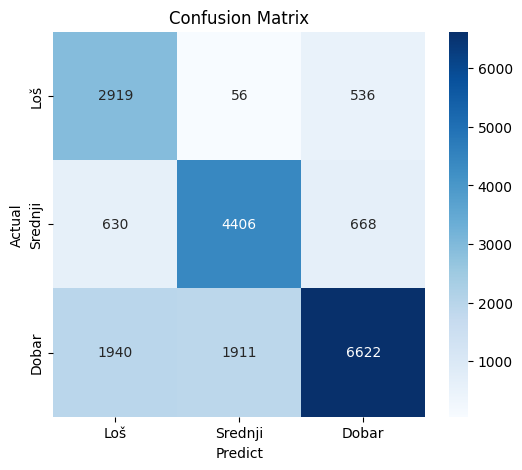

In [ ]:
# Konfuzijska matrica
cm = confusion_matrix(y_test, y_pred)

# Iscrtavanje konfuzijske matrice
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Loš', 'Srednji', "Dobar"], yticklabels=['Loš', 'Srednji', "Dobar"])
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.title('Confusion Matrix')
plt.show()


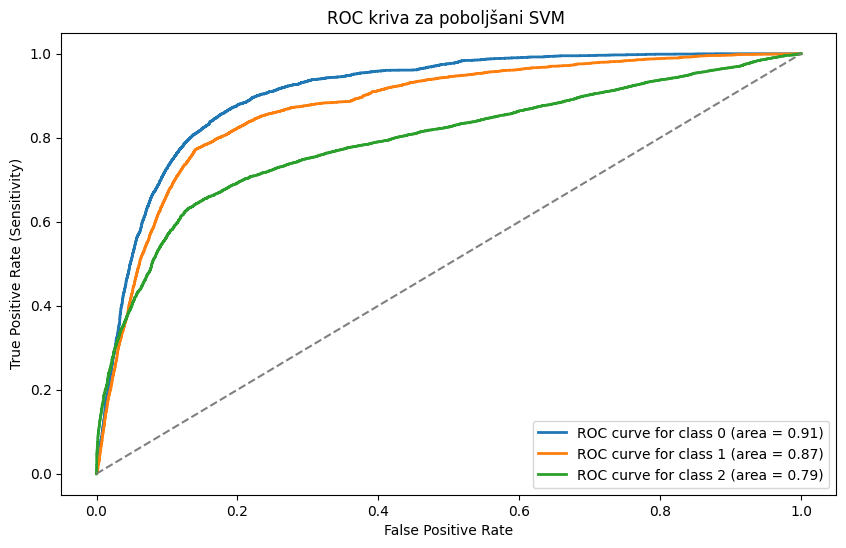

In [ ]:
y_score = best_svc.decision_function(X_test)

# Postavljanje figure za prikaz
plt.figure(figsize=(10, 6))

# Iscrtavanje ROC krivih za svaku klasu
n_classes = y_score.shape[1]  # Broj klasa
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test, y_score[:, i], pos_label=i)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve for class {i} (area = {roc_auc:0.2f})')

# Dodavanje dijagonalne linije (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Dodavanje oznaka i legendi
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC kriva za poboljšani SVM ')
plt.legend(loc='lower right')

# Prikazivanje grafika
plt.show()

## Test

In [ ]:
optimal_params = {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

# Kreirajte SVM model sa najboljim parametrima
best_svm = SVC(**optimal_params)

# Unakrsna validacija na trening skupu (5-folds)
cv_scores = cross_val_score(best_svm, X_train, y_train, cv=5, scoring='accuracy')

# Ispis prosečne tačnosti tokom kros-validacije
print(f"Average Cross-Validation Accuracy: {cv_scores.mean()}")

# Treniranje modela sa celokupnim trening podacima
best_svm.fit(X_train, y_train)

# Predviđanje na testnim podacima
y_pred = best_svm.predict(X_test)

# Ispis klasiifikacijskog izveštaja
print("Classification Report:")
print(classification_report(y_test, y_pred))


Average Cross-Validation Accuracy: 0.7393799361996034
Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.83      0.65      3511
           1       0.69      0.77      0.73      5704
           2       0.85      0.63      0.72     10473

    accuracy                           0.71     19688
   macro avg       0.69      0.75      0.70     19688
weighted avg       0.75      0.71      0.71     19688



In [ ]:
# Kreiranje i ispis matrice konfuzije
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2919   56  536]
 [ 630 4406  668]
 [1940 1911 6622]]
